# Prediction of Immunological Non-Response to ART in HIV-Positive Adults in Sub-Saharan Africa

**By:** Jerome Bright Ogenrwot | 2025/HD07/26019U | 250026019U

**Course:** Machine Learning in Biomedicine  

**Dataset:** Nigeria Quality of Care HIV Dataset (N=27,288)

**Dataset_Source:** Kaggle

## 1. Setup and Imports

In [1]:
# Installing  neccesary packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, brier_score_loss, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

# Styles
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
RANDOM_STATE = 42

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading and Exploration

In [2]:
# Load dataset
df = pd.read_excel('QualityOfCare.xlsx')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset shape: (27288, 46)

Column names:
['Health facility level', 'FacilityType', 'FundingSources', 'DateOfBirth', 'Age', 'AgeInMonths', 'Sex', 'MaritalStatus', 'EducationLevel', 'Occupation', 'DateOfConfirmedHIV', 'DateOfEnrollment', 'CareEntryPoint', 'DateArtStarted', 'RegimenAtStart', 'WeightAtStart', 'HeightUnit', 'HeightAtStart', 'FunctionalStatusAtStart', 'ClinicalStageAtStart', 'Cd4Unit', 'Cd4AtStart', 'AdherenceCouncelingCompleted', 'InitialTbScreeningDone', 'ArtSubstitution', 'ArtSwitch', 'ArtInterruption', 'PatientDead', 'ClinicalStageAtLastVisit', 'TbStatusAtLAstVisit', 'WeightAtLastVisit', 'HeightAtLastVisit', 'OpportunisticInfectionPresentAtLastVisit', 'AnySideEffects', 'WasPatientReceivingArv', 'ArvAdherenceLatestLevel', 'MostRecentCd4Count', 'ViralLoadDone', 'PregnancyStatus', 'ArtInterruptionType', 'ArtInterruptionDate', 'ArtInterruptionReason', 'OpportunisticInfectionAtLastVisit', 'OpportunisticInfectionAtLastVisitOthers', 'CurrentRegimen', 'ViralLoad']


In [3]:
# Overview of the Dataset
print('DATASET OVERVIEW')
print(f'Total patients: {len(df):,}')
print(f'Total features: {df.shape[1]}')
print(f'\nMissing values per column:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

DATASET OVERVIEW
Total patients: 27,288
Total features: 46

Missing values per column:
                                          Missing Count  Missing %
AgeInMonths                                       26646       97.6
OpportunisticInfectionAtLastVisitOthers           26293       96.4
ArtInterruptionReason                             25611       93.9
ArtInterruptionDate                               24978       91.5
ArtInterruptionType                               24921       91.3
OpportunisticInfectionAtLastVisit                 24414       89.5
ViralLoad                                         13525       49.6
HeightAtLastVisit                                 12057       44.2
HeightAtStart                                     11931       43.7
PregnancyStatus                                   10707       39.2
HeightUnit                                         9443       34.6
MostRecentCd4Count                                 7182       26.3
Cd4AtStart                                

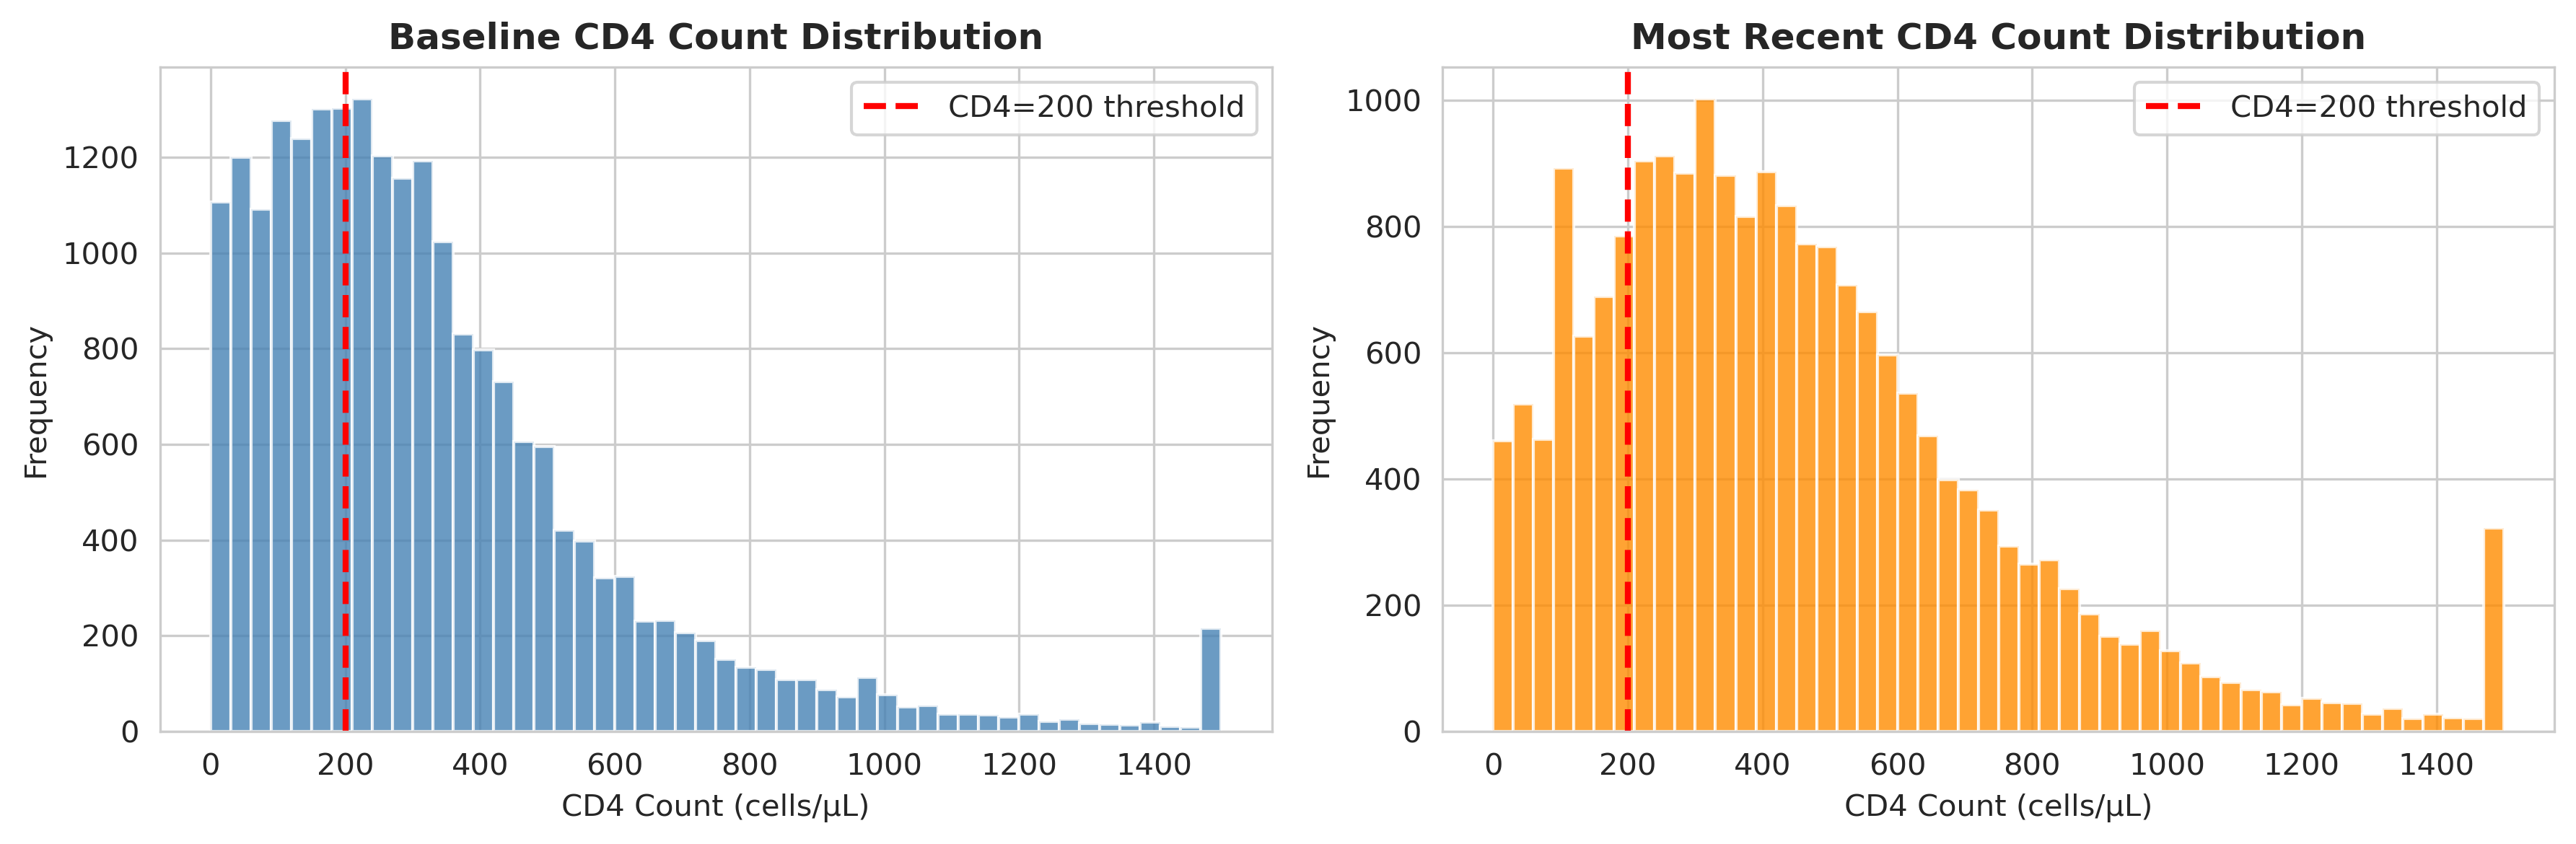

Figure 1 saved.


In [4]:
# Visualise CD4 distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Limit extreme outliers for visualisation
cd4_start_cap = df['Cd4AtStart'].clip(upper=1500)
cd4_recent_cap = df['MostRecentCd4Count'].clip(upper=1500)

axes[0].hist(cd4_start_cap.dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(200, color='red', linestyle='--', linewidth=2, label='CD4=200 threshold')
axes[0].set_title('Baseline CD4 Count Distribution', fontweight='bold')
axes[0].set_xlabel('CD4 Count (cells/µL)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(cd4_recent_cap.dropna(), bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(200, color='red', linestyle='--', linewidth=2, label='CD4=200 threshold')
axes[1].set_title('Most Recent CD4 Count Distribution', fontweight='bold')
axes[1].set_xlabel('CD4 Count (cells/µL)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_cd4_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 3. Defining The Outcome Variable 

**Immunological Non-Response (INR)** to antiretroviral therapy (ART) is a critical concern for PLHIV, characterized by inadequate CD4+ T-cell recovery despite successful virological suppressionas (Rachman et al., 2025). In the context of the source dataset study, it was defined as defined failure to achieve CD4 ≥ 200 cells/µL at most recent follow-up among patients who initiated ART with baseline CD4 < 200 cells/µL. This definition is consistent with established clinical literature on ART immunological outcomes in Sub-Saharan Africa.

In [5]:
# Filter patients with both CD4 measurements and baseline CD4 below 200
# First remove extreme outliers ( that could be due data entry errors)
df_clean = df[
    (df['Cd4AtStart'].notna()) &
    (df['MostRecentCd4Count'].notna()) &
    (df['Cd4AtStart'] < 2000) &  # remove data entry errors
    (df['MostRecentCd4Count'] < 2000)
].copy()

# Focus on patients who started immunologically compromised
df_inr = df_clean[df_clean['Cd4AtStart'] < 200].copy()

# Define outcome: 1 = Non-Responder, 0 = Responder
df_inr['INR'] = (df_inr['MostRecentCd4Count'] < 200).astype(int)

print(f'Patients with baseline CD4 < 200: {len(df_inr):,}')
print(f'\nOutcome distribution:')
print(f'  Immunological Non-Responders (INR=1): {df_inr["INR"].sum():,} ({df_inr["INR"].mean()*100:.1f}%)')
print(f'  Immunological Responders    (INR=0): {(df_inr["INR"]==0).sum():,} ({(1-df_inr["INR"].mean())*100:.1f}%)')

Patients with baseline CD4 < 200: 6,699

Outcome distribution:
  Immunological Non-Responders (INR=1): 3,085 (46.1%)
  Immunological Responders    (INR=0): 3,614 (53.9%)


In [ ]:
# Visualise outcome distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = df_inr['INR'].value_counts()
labels = ['Responder\n(INR=0)', 'Non-Responder\n(INR=1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Immunological Non-Response Distribution', fontweight='bold')

# CD4 trajectory comparison
responders = df_inr[df_inr['INR'] == 0]
non_responders = df_inr[df_inr['INR'] == 1]

axes[1].scatter(responders['Cd4AtStart'].clip(upper=200), 
                responders['MostRecentCd4Count'].clip(upper=800),
                alpha=0.3, color='#2ecc71', s=10, label='Responder')
axes[1].scatter(non_responders['Cd4AtStart'].clip(upper=200),
                non_responders['MostRecentCd4Count'].clip(upper=800),
                alpha=0.3, color='#e74c3c', s=10, label='Non-Responder')
axes[1].axhline(200, color='black', linestyle='--', linewidth=1.5, label='CD4=200 threshold')
axes[1].set_xlabel('Baseline CD4 Count (cells/µL)')
axes[1].set_ylabel('Most Recent CD4 Count (cells/µL)')
axes[1].set_title('CD4 Trajectory by Outcome', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig2_outcome_distribution.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 4. Feature Engineering

Features are engineered as **exhaustion-informed clinical proxies** — variables that serve as computational surrogates of T-cell exhaustion severity, grounded in established HIV immunology literature.

In [ ]:
# Parse dates
for col in ['DateOfConfirmedHIV', 'DateArtStarted']:
    df_inr[col] = pd.to_datetime(df_inr[col], errors='coerce')

# Feature 1: Treatment Delay Index
# Days from HIV diagnosis to ART start — longer delay = deeper exhaustion
df_inr['TreatmentDelayDays'] = (
    df_inr['DateArtStarted'] - df_inr['DateOfConfirmedHIV']
).dt.days
df_inr['TreatmentDelayDays'] = df_inr['TreatmentDelayDays'].clip(lower=0, upper=3650)

# Feature 2: Advanced Disease Indicator
# WHO clinical stage III or IV = advanced immune suppression
df_inr['AdvancedDisease'] = df_inr['ClinicalStageAtStart'].isin(['III', 'IV']).astype(int)

# Feature 3: Baseline CD4 (continuous)
df_inr['BaselineCD4'] = df_inr['Cd4AtStart']

# Feature 4: ART Adherence Score
adherence_map = {'Good': 2, 'Fair': 1, 'Poor': 0}
df_inr['AdherenceScore'] = df_inr['ArvAdherenceLatestLevel'].map(adherence_map)

# Feature 5: ART Interruption
df_inr['ArtInterruptionBinary'] = (df_inr['ArtInterruption'] == 'Yes').astype(int)

# Feature 6: ART Regimen Switch
df_inr['ArtSwitchBinary'] = (df_inr['ArtSwitch'] == 'Yes').astype(int)

# Feature 7: Functional Status at Start
functional_map = {'Working': 2, 'Ambulatory': 1, 'Bedridden': 0}
df_inr['FunctionalStatusScore'] = df_inr['FunctionalStatusAtStart'].map(functional_map)

# Feature 8: Age
df_inr['Age'] = df_inr['Age']

# Feature 9: Sex
df_inr['SexBinary'] = (df_inr['Sex'] == 'Female').astype(int)

# Feature 10: Facility Level
facility_map = {'Primary health centre': 0, 'Secondary hospital': 1, 'Tertiary hospital': 2}
df_inr['FacilityLevelScore'] = df_inr['Health facility level'].map(facility_map)

# Feature 11: Opportunistic Infection at last visit
df_inr['OpportunisticInfection'] = (
    df_inr['OpportunisticInfectionPresentAtLastVisit'] == 'Yes'
).astype(int)

# Feature 12: Weight at start (nutritional proxy)
df_inr['WeightAtStart'] = df_inr['WeightAtStart']

print('Feature engineering complete.')
print(f'Features engineered: 12')

In [ ]:
# Define final feature set
FEATURES = [
    'BaselineCD4',
    'TreatmentDelayDays',
    'AdvancedDisease',
    'AdherenceScore',
    'ArtInterruptionBinary',
    'ArtSwitchBinary',
    'FunctionalStatusScore',
    'Age',
    'SexBinary',
    'FacilityLevelScore',
    'OpportunisticInfection',
    'WeightAtStart'
]

TARGET = 'INR'

# Prepare final dataset
df_model = df_inr[FEATURES + [TARGET]].copy()
df_model = df_model.dropna(subset=[TARGET])

print(f'Final modelling dataset shape: {df_model.shape}')
print(f'Class distribution:')
print(df_model[TARGET].value_counts())

In [ ]:
# Feature correlation heatmap
plt.figure(figsize=(12, 9))
corr_matrix = df_model[FEATURES].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 5. Data Preprocessing and Train-Test Split

In [ ]:
X = df_model[FEATURES]
y = df_model[TARGET]

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Apply SMOTE to handle class imbalance on training set
smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f'\nAfter SMOTE:')
print(f'  Class 0 (Responders):     {(y_train_balanced==0).sum():,}')
print(f'  Class 1 (Non-Responders): {(y_train_balanced==1).sum():,}')

## 6. Model Training

In [ ]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0
    ),
    'Neural Network (MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500,
        random_state=RANDOM_STATE, early_stopping=True
    )
}

# Train all models and collect results
results = {}
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    results[name] = {
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Brier Score': round(brier_score_loss(y_test, y_prob), 4),
        'Avg Precision': round(average_precision_score(y_test, y_prob), 4)
    }
    trained_models[name] = (model, y_pred, y_prob)
    print(f'  AUC-ROC: {results[name]["AUC-ROC"]} | F1: {results[name]["F1 Score"]}')

print('\nAll models trained.')

In [ ]:
# Results table
results_df = pd.DataFrame(results).T
print('=== MODEL PERFORMANCE COMPARISON ===')
print(results_df.to_string())

## 7. Evaluation and Visualisation

In [ ]:
# ROC Curves
plt.figure(figsize=(8, 6))
colors_roc = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']

for (name, (model, y_pred, y_prob)), color in zip(trained_models.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results[name]['AUC-ROC']
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig4_roc_curves.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

In [ ]:
# Precision-Recall Curves
plt.figure(figsize=(8, 6))

for (name, (model, y_pred, y_prob)), color in zip(trained_models.items(), colors_roc):
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = results[name]['Avg Precision']
    plt.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AP={ap})')

baseline = y_test.mean()
plt.axhline(baseline, color='gray', linestyle='--', linewidth=1, label=f'Baseline (prevalence={baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontweight='bold', fontsize=13)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_precision_recall_curves.png', bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

In [ ]:
# Performance comparison bar chart
metrics = ['AUC-ROC', 'F1 Score', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, color) in enumerate(zip(results.keys(), colors_roc)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0.8, color='gray', linestyle=':', linewidth=1, alpha=0.7)
plt.tight_layout()
plt.savefig('fig6_performance_comparison.png', bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

In [ ]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, (model, y_pred, y_prob)), color in zip(axes, trained_models.items(), colors_roc):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Responder', 'Non-Responder'],
                yticklabels=['Responder', 'Non-Responder'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAUC={results[name]["AUC-ROC"]}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

plt.suptitle('Confusion Matrices — All Models', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

## 8. Hyperparameter Optimisation (Best Model)

In [ ]:
# Identify best model by AUC-ROC
best_model_name = max(results, key=lambda x: results[x]['AUC-ROC'])
print(f'Best model: {best_model_name} (AUC-ROC: {results[best_model_name]["AUC-ROC"]})')
print('\nOptimising best model with GridSearchCV...')

# XGBoost param grid
if 'XGBoost' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
    base_model = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
elif 'Random Forest' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    base_model = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
else:
    param_grid = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    base_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(base_model, param_grid, cv=cv, scoring='roc_auc',
                           n_jobs=-1, verbose=0)
grid_search.fit(X_train_balanced, y_train_balanced)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV AUC-ROC: {grid_search.best_score_:.4f}')

# Evaluate optimised model
best_opt_model = grid_search.best_estimator_
y_pred_opt = best_opt_model.predict(X_test_scaled)
y_prob_opt = best_opt_model.predict_proba(X_test_scaled)[:, 1]

print(f'\nOptimised Model Test Performance:')
print(f'  AUC-ROC:   {roc_auc_score(y_test, y_prob_opt):.4f}')
print(f'  F1 Score:  {f1_score(y_test, y_pred_opt):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_opt):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_opt):.4f}')

## 9. SHAP Explainability Analysis

In [ ]:
print('Computing SHAP values...')

# Use tree explainer for XGBoost/RF, linear for LR
if 'XGBoost' in best_model_name or 'Random Forest' in best_model_name:
    explainer = shap.TreeExplainer(best_opt_model)
    shap_values = explainer.shap_values(X_test_scaled)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # class 1
else:
    explainer = shap.LinearExplainer(best_opt_model, X_train_balanced)
    shap_values = explainer.shap_values(X_test_scaled)

# SHAP Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_scaled,
    feature_names=FEATURES,
    plot_type='dot',
    show=False,
    max_display=12
)
plt.title(f'SHAP Feature Importance — {best_model_name} (Optimised)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig8_shap_summary.png', bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

In [ ]:
# SHAP Bar Plot — Mean absolute importance
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test_scaled,
    feature_names=FEATURES,
    plot_type='bar',
    show=False,
    max_display=12
)
plt.title(f'Mean SHAP Feature Importance — {best_model_name}', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig9_shap_bar.png', bbox_inches='tight')
plt.show()
print('Figure 9 saved.')

## 10. Final Results Summary

In [ ]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'\nDataset: Nigeria Quality of Care HIV Dataset')
print(f'Study population: HIV-positive adults on ART with baseline CD4 < 200')
print(f'Total samples: {len(df_model):,}')
print(f'Outcome: Immunological Non-Response (INR)')
print(f'  Non-Responders: {df_model[TARGET].sum():,} ({df_model[TARGET].mean()*100:.1f}%)')
print(f'  Responders:     {(df_model[TARGET]==0).sum():,} ({(1-df_model[TARGET].mean())*100:.1f}%)')
print(f'\nModel Performance:')
print(results_df.to_string())
print(f'\nBest Model: {best_model_name}')
print(f'Optimised AUC-ROC: {roc_auc_score(y_test, y_prob_opt):.4f}')
print(f'Optimised F1:      {f1_score(y_test, y_pred_opt):.4f}')
print('\nTop predictive features (from SHAP):')
shap_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)
print(shap_importance.to_string(index=False))
print('=' * 60)

## 11. Figures Generated

| Figure | Description |
|--------|-------------|
| fig1_cd4_distribution.png | Baseline and follow-up CD4 distributions |
| fig2_outcome_distribution.png | INR class distribution and CD4 trajectory |
| fig3_correlation_heatmap.png | Feature correlation matrix |
| fig4_roc_curves.png | ROC curves for all four models |
| fig5_precision_recall_curves.png | Precision-recall curves |
| fig6_performance_comparison.png | Bar chart comparing all metrics across models |
| fig7_confusion_matrices.png | Confusion matrices for all models |
| fig8_shap_summary.png | SHAP dot summary plot |
| fig9_shap_bar.png | SHAP mean importance bar plot |